In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [13]:
# Load ALL Datasets

ds1 = pd.read_csv("DS1_material_properties_5500.csv")
ds2 = pd.read_csv("DS2_commodity_prices_10yr.csv")
ds3 = pd.read_csv("DS3_infrastructure_bridges_5000.csv")
ds4 = pd.read_csv("DS4_crossdomain_features_daily.csv")
ds5 = pd.read_csv("DS5_element_prices_monthly.csv")
ds6 = pd.read_csv("DS6_historical_failures_2000.csv")

print("All datasets loaded...")

All datasets loaded...


In [14]:
ds1.head()

,material_id,formula,n_elements,crystal_system,spacegroup_number,category,formation_energy_per_atom_eV,energy_above_hull_eV,band_gap_eV,is_metal,bulk_modulus_GPa,shear_modulus_GPa,poisson_ratio,density_g_cm3,nsites,volume_A3,melting_point_K,is_stable
0,mp-121959,Ta3Au3H2,3,hexagonal,185,Chalcogenide,-0.6329,0.0175,1.940,0,26.87,13.47,0.2918,4.343,2,96.38,1142.0,1
1,mp-23248,Al3Rh4W3,3,hexagonal,171,Alloy,-1.2275,0.2124,0.000,1,50.30,33.94,0.2326,6.757,4,365.02,1244.0,0
2,mp-526982,Pd3Te3,2,cubic,227,Metal,0.1265,0.0993,0.000,1,256.03,125.93,0.2849,10.501,4,642.24,1178.0,0
3,mp-984775,Ne4Cd4,2,tetragonal,81,Nitride,-0.4655,0.0534,1.830,0,461.87,233.17,0.2888,1.754,32,820.52,1130.0,0
4,mp-965909,Al4Rh,2,cubic,202,Nitride,-0.6142,0.0501,1.264,0,187.79,148.00,0.1900,3.360,2,87.85,306.0,0


In [15]:
# Data Cleaning
# DS1 (Material)
ds1 = ds1[
    (ds1["bulk_modulus_GPa"] > 0) &
    (ds1["shear_modulus_GPa"] > 0) &
    (ds1["density_g_cm3"] > 0)
]

ds1.fillna(ds1.mean(numeric_only=True), inplace=True)

# DS3 (Infrastructure)
ds3.fillna(ds3.mean(numeric_only=True), inplace=True)

# DS6 (Failures)
ds6.fillna(ds6.mean(numeric_only=True), inplace=True)

print("Cleaning Done...")


Cleaning Done...


In [16]:
df_market = pd.merge(ds2, ds4, on=["date", "commodity"])
df_market.dropna(inplace=True)

print("Market Data Ready:", df_market.shape)

Market Data Ready: (22448, 34)


In [17]:
# Feature Engineering

# Infrastructure risk feature
ds3["risk_factor"] = ds3["corrosion_rate_mm_yr"] * ds3["age_years"]

# Thickness degradation
ds3["degradation"] = ds3["original_thickness_mm"] - ds3["remaining_thickness_mm"]

# Material quality index
ds1["quality_index"] = ds1["bulk_modulus_GPa"] / ds1["density_g_cm3"]

print("Feature Engineering Done...")

Feature Engineering Done...


Model

In [18]:
# Failure Prediction

X_fail = ds3.drop(["condition_rating"], axis=1)
y_fail = ds3["condition_rating"]

X_fail = pd.get_dummies(X_fail)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_fail, y_fail, test_size=0.2)

model_failure = RandomForestClassifier(n_estimators=100)
model_failure.fit(Xf_train, yf_train)

pred_fail = model_failure.predict(Xf_test)

print("Failure Model Accuracy:", accuracy_score(yf_test, pred_fail))

Failure Model Accuracy: 0.556


In [19]:
# Financial Loss Prediction

X_loss = ds6.drop(["repair_cost_USD"], axis=1)
y_loss = ds6["repair_cost_USD"]

X_loss = pd.get_dummies(X_loss)

Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_loss, y_loss, test_size=0.2)

model_loss = RandomForestRegressor(n_estimators=100)
model_loss.fit(Xl_train, yl_train)

pred_loss = model_loss.predict(Xl_test)

print("Loss Model MSE:", mean_squared_error(yl_test, pred_loss))

Loss Model MSE: 81501017809.90698


In [20]:
# Commodity Prediction

df_market = pd.get_dummies(df_market)

X_market = df_market.drop(["close"], axis=1)
y_market = df_market["close"]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(X_market, y_market, test_size=0.2)

model_market = LinearRegression()
model_market.fit(Xm_train, ym_train)

pred_market = model_market.predict(Xm_test)

print("Commodity Model MSE:", mean_squared_error(ym_test, pred_market))

Commodity Model MSE: 215.71313640466116


In [22]:
# FINAL RISK

# Risk = PD × Expected Loss

# Predict loss on SAME test size
loss_values = model_loss.predict(Xl_test)

# Make sizes equal
min_len = min(len(pd_prob), len(loss_values))

pd_prob = pd_prob[:min_len]
loss_values = loss_values[:min_len]

# Final risk
risk_score = pd_prob * loss_values

print("Sample Risk Scores:", risk_score[:5])

Sample Risk Scores: [   0.     6049.9919    0.        0.        0.    ]


In [23]:
# SIMULATION SYSTEM

def simulate_bridge(input_data):
    input_df = pd.DataFrame([input_data], columns=X_fail.columns)
    
    # Failure risk
    risk = model_failure.predict_proba(input_df)[0][1]
    
    # Use average loss
    loss = model_loss.predict(X_loss.iloc[:1])[0]
    
    return {
        "Failure Risk": float(risk),
        "Expected Loss ($)": float(loss),
        "Final Risk Score": float(risk * loss)
    }

# Example
print(simulate_bridge(X_fail.iloc[0]))

{'Failure Risk': 0.0, 'Expected Loss ($)': 27318.82, 'Final Risk Score': 0.0}


Visualization

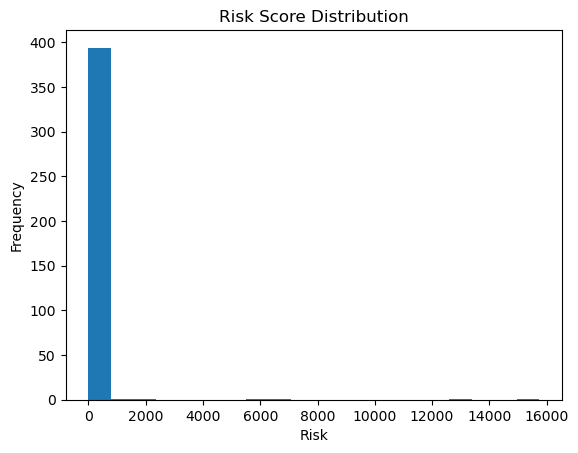

In [24]:
import matplotlib.pyplot as plt

plt.hist(risk_score, bins=20)
plt.title("Risk Score Distribution")
plt.xlabel("Risk")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Save Models
import joblib

joblib.dump(model_failure, "failure_model.pkl")
joblib.dump(model_loss, "loss_model.pkl")
joblib.dump(model_market, "market_model.pkl")

print("Models Saved...")

Models Saved...
